In [2]:
import torch
print("PyTorch :", torch.__version__)
print("CUDA :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
else:
    print("GPU : not available")

PyTorch : 2.5.1+cu121
CUDA : True
GPU : NVIDIA GeForce RTX 3050 Laptop GPU


# 1. SETUP

In [3]:
import os
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device :", device)
if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass
else:
    print("GPU not detected, using CPU only")

plt.style.use("seaborn-v0_8-whitegrid")

Device : cuda
GPU : NVIDIA GeForce RTX 3050 Laptop GPU


# 2. CONFIG

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32  # Sesuaikan kemampuan GPU

TRAIN_DIR = Path("data/processed/train")
VAL_DIR = Path("data/processed/validation")
TEST_DIR = Path("data/processed/test")

EPOCHS = 50  # Bisa diubah
FINE_TUNE_EPOCHS = 25  # Epoch untuk fine-tuning

INITIAL_LR = 1e-4  # Learning rate di 0.0001
FINE_TUNE_LR = 1e-5  # Learning rate di 0.00001 untuk fine-tuning

# Kontrol training: default jalankan full epoch (tanpa stop otomatis)
USE_EARLY_STOPPING = True
EARLY_STOP_PATIENCE = 10
EARLY_STOP_START_EPOCH = 3

NUM_CLASSES = 4

REPORT_DIR = Path("reports")
FIG_DIR = REPORT_DIR / "figures"
METRICS_DIR = REPORT_DIR / "metrics"
CHECKPOINT_DIR = Path("models") / "checkpoints"
BEST_MODEL_PATH = Path("models") / "best_model.pt"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
Path("models").mkdir(parents=True, exist_ok=True)

# 3. LOAD DATASET

In [7]:
from torchvision import datasets, transforms

# Data hasil preprocess sudah berada di data/processed dan berukuran seragam,
# jadi loader cukup melakukan resize aman dan konversi ke tensor.
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=eval_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

class_names = train_dataset.classes

print("Train samples :", len(train_dataset))
print("Validation samples :", len(val_dataset))
print("Test samples :", len(test_dataset))

Train samples : 2240
Validation samples : 240
Test samples : 240


# 4. CALLBACK

In [8]:
# Pengganti callback TensorFlow: checkpoint, early stopping, dan kontrol LR ada di training loop PyTorch.

train_control = {
    "use_early_stopping": USE_EARLY_STOPPING,
    "early_stop_patience": EARLY_STOP_PATIENCE,
    "early_stop_start_epoch": EARLY_STOP_START_EPOCH,
    "lr_factor": 0.5,
    "lr_patience": 3,
    "min_lr": 1e-7,
    "use_amp": torch.cuda.is_available(),
}


def save_checkpoint(model, path):
    torch.save(model.state_dict(), path)


print("Training control :", train_control)
print("Best model path :", BEST_MODEL_PATH)

Training control : {'use_early_stopping': True, 'early_stop_patience': 10, 'early_stop_start_epoch': 3, 'lr_factor': 0.5, 'lr_patience': 3, 'min_lr': 1e-07, 'use_amp': True}
Best model path : models\best_model.pt


# 5. FUNCTION EVALUASI

In [9]:
def evaluate_loss_accuracy(model, loader, criterion=None):
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            running_correct += (predictions == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, running_correct / total


def predict_proba(model, loader):
    model.eval()
    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            outputs = model(images)
            probabilities = torch.softmax(outputs, dim=1)

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(outputs.argmax(dim=1).cpu().numpy().tolist())
            y_prob.extend(probabilities.cpu().numpy().tolist())

    return np.array(y_true), np.array(y_pred), np.array(y_prob)


def evaluate_model(model, model_name, return_details=False, show_plot=True):
    print(f"\n=== {model_name} ===")

    loss, acc = evaluate_loss_accuracy(model, test_loader)
    print("Accuracy :", acc)
    print("Loss :", loss)

    y_true, y_pred, y_prob = predict_proba(model, test_loader)

    report_text = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
    )
    report_dict = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
        output_dict=True,
    )

    print("\nClassification Report :")
    print(report_text)

    cm = confusion_matrix(y_true, y_pred)
    if show_plot:
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {model_name}")
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.tight_layout()
        plt.show()

    if return_details:
        return {
            "model_name": model_name,
            "accuracy": float(acc),
            "loss": float(loss),
            "y_true": y_true,
            "y_pred": y_pred,
            "y_prob": y_prob,
            "class_names": class_names,
            "report_dict": report_dict,
            "confusion_matrix": cm,
        }

    return acc

# 6. MODEL

## A. MobileNetV2 (Tanpa Pretrained - Belajar dari 0)

In [10]:
def build_mobilenet():
    model = models.mobilenet_v2(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
    return model, None


def build_efficientnet():
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
    return model, None


class FusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.mobilenet = models.mobilenet_v2(weights=None).features
        self.efficientnet = models.efficientnet_b0(weights=None).features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Linear(1280 + 1280, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256, NUM_CLASSES),
        )

    def forward(self, x):
        x1 = self.pool(self.mobilenet(x)).flatten(1)
        x2 = self.pool(self.efficientnet(x)).flatten(1)
        fusion = torch.cat([x1, x2], dim=1)
        return self.classifier(fusion)


def build_fusion():
    return FusionModel(), None, None

## B. EfficientNetB0 (Tanpa Pretrained - Belajar dari 0)

In [16]:
def build_efficientnet():
    model = models.efficientnet_b0(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
    return model, None

## C. Hybrid (Feature Fusion)

In [17]:
def build_fusion():
    model = FusionModel()
    return model, None, None

# 7. Training Function (2 Tahap)

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=device.type == "cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        running_correct += (predictions == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, running_correct / total


def fit_stage(model, train_loader, val_loader, epochs, lr):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=train_control["lr_factor"],
        patience=train_control["lr_patience"],
        min_lr=train_control["min_lr"],
    )
    scaler = torch.amp.GradScaler("cuda", enabled=train_control["use_amp"])

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = float("inf")
    patience_counter = 0
    history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}

    start_time = time.perf_counter()
    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_acc = evaluate_loss_accuracy(model, val_loader, criterion)
        scheduler.step(val_loss)

        history["loss"].append(train_loss)
        history["accuracy"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_acc)

        print(
            f"Epoch {epoch + 1:02d} | "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}"
        )

        if train_control["use_early_stopping"] and (epoch + 1) >= EARLY_STOP_START_EPOCH:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_state = copy.deepcopy(model.state_dict())
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= EARLY_STOP_PATIENCE:
                    print("Early stopping triggered.")
                    break
        elif val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

    total_time = time.perf_counter() - start_time
    model.load_state_dict(best_state)
    return model, history, total_time


def train_model(model, base_model=None):
    _ = base_model

    model, history_stage1, stage1_time = fit_stage(
        model,
        train_loader,
        val_loader,
        epochs=EPOCHS,
        lr=INITIAL_LR,
    )

    model, history_stage2, stage2_time = fit_stage(
        model,
        train_loader,
        val_loader,
        epochs=FINE_TUNE_EPOCHS,
        lr=FINE_TUNE_LR,
    )

    history_bundle = {
        "stage1": history_stage1,
        "stage2": history_stage2,
    }
    timing_bundle = {
        "stage1_sec": stage1_time,
        "stage2_sec": stage2_time,
        "total_sec": stage1_time + stage2_time,
    }

    return model, history_bundle, timing_bundle

# 8. Train & Evaluasi Model

## A. MobileNetV2

Epoch 01 | train_loss=1.3672 train_acc=0.3054 val_loss=1.6209 val_acc=0.2542
Epoch 02 | train_loss=1.3221 train_acc=0.3429 val_loss=1.3208 val_acc=0.3375
Epoch 03 | train_loss=1.2425 train_acc=0.4040 val_loss=1.2790 val_acc=0.4167
Epoch 04 | train_loss=1.1715 train_acc=0.4536 val_loss=1.3250 val_acc=0.3958
Epoch 05 | train_loss=1.0735 train_acc=0.5192 val_loss=1.3538 val_acc=0.4292
Epoch 06 | train_loss=0.9845 train_acc=0.5884 val_loss=1.4067 val_acc=0.4333
Epoch 07 | train_loss=0.9199 train_acc=0.6049 val_loss=1.3843 val_acc=0.4292
Epoch 08 | train_loss=0.7903 train_acc=0.6741 val_loss=1.3828 val_acc=0.4792
Epoch 09 | train_loss=0.6963 train_acc=0.7103 val_loss=1.4547 val_acc=0.4542
Epoch 10 | train_loss=0.6557 train_acc=0.7335 val_loss=1.4412 val_acc=0.4667
Epoch 11 | train_loss=0.6279 train_acc=0.7455 val_loss=1.6856 val_acc=0.4208
Epoch 12 | train_loss=0.5547 train_acc=0.7763 val_loss=1.5076 val_acc=0.4708
Epoch 13 | train_loss=0.5110 train_acc=0.8027 val_loss=1.6325 val_acc=0.4458

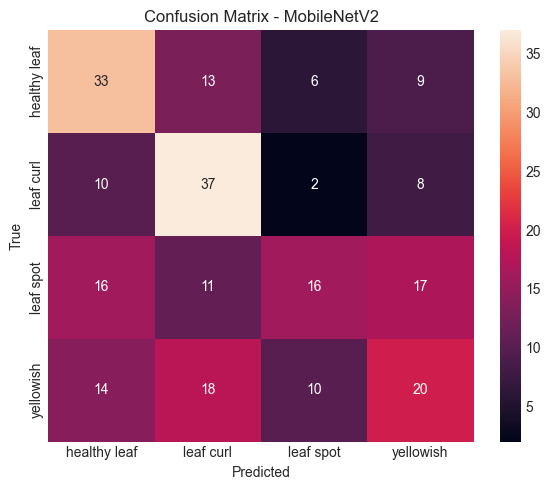

In [21]:
model_m, base_m = build_mobilenet()
model_m, history_m, timing_m = train_model(model_m, base_m)
eval_m = evaluate_model(model_m, "MobileNetV2", return_details=True)
acc_m = eval_m["accuracy"]

## B. EfficientNetB0

Epoch 01 | train_loss=1.3837 train_acc=0.2991 val_loss=1.4049 val_acc=0.2542
Epoch 02 | train_loss=1.3518 train_acc=0.3464 val_loss=1.2893 val_acc=0.3750
Epoch 03 | train_loss=1.2587 train_acc=0.4330 val_loss=1.3018 val_acc=0.4583
Epoch 04 | train_loss=1.1353 train_acc=0.5165 val_loss=1.1588 val_acc=0.5083
Epoch 05 | train_loss=0.9890 train_acc=0.5924 val_loss=1.3050 val_acc=0.4917
Epoch 06 | train_loss=0.8904 train_acc=0.6326 val_loss=1.1410 val_acc=0.5375
Epoch 07 | train_loss=0.7475 train_acc=0.7063 val_loss=1.4045 val_acc=0.5292
Epoch 08 | train_loss=0.6154 train_acc=0.7688 val_loss=1.2537 val_acc=0.5208
Epoch 09 | train_loss=0.5505 train_acc=0.7884 val_loss=1.3381 val_acc=0.5375
Epoch 10 | train_loss=0.4337 train_acc=0.8371 val_loss=1.1687 val_acc=0.5792
Epoch 11 | train_loss=0.3634 train_acc=0.8621 val_loss=1.3690 val_acc=0.5833
Epoch 12 | train_loss=0.3112 train_acc=0.8857 val_loss=1.2685 val_acc=0.5708
Epoch 13 | train_loss=0.2902 train_acc=0.9013 val_loss=1.3922 val_acc=0.5875

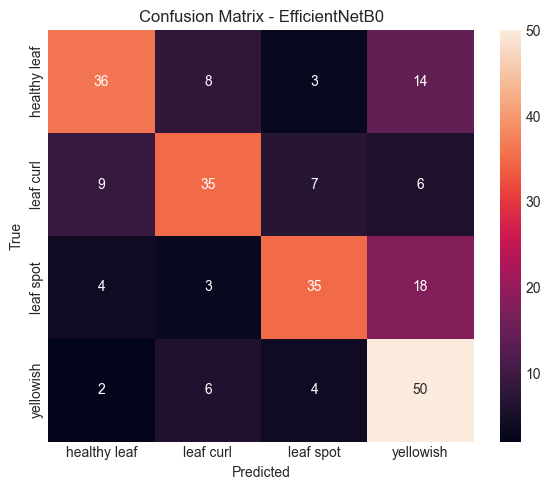

In [22]:
model_e, base_e = build_efficientnet()
model_e, history_e, timing_e = train_model(model_e, base_e)
eval_e = evaluate_model(model_e, "EfficientNetB0", return_details=True)
acc_e = eval_e["accuracy"]

## C. Hybrid Model

Epoch 01 | train_loss=1.4402 train_acc=0.3161 val_loss=1.6218 val_acc=0.2167
Epoch 02 | train_loss=1.3653 train_acc=0.3518 val_loss=1.2790 val_acc=0.3875
Epoch 03 | train_loss=1.2951 train_acc=0.3973 val_loss=1.2156 val_acc=0.3875
Epoch 04 | train_loss=1.2255 train_acc=0.4571 val_loss=1.1110 val_acc=0.5083
Epoch 05 | train_loss=1.1210 train_acc=0.5330 val_loss=1.0331 val_acc=0.5833
Epoch 06 | train_loss=1.0159 train_acc=0.5737 val_loss=1.0177 val_acc=0.5583
Epoch 07 | train_loss=0.9456 train_acc=0.6147 val_loss=1.0123 val_acc=0.5875
Epoch 08 | train_loss=0.8564 train_acc=0.6683 val_loss=1.0443 val_acc=0.5708
Epoch 09 | train_loss=0.7312 train_acc=0.7170 val_loss=1.1927 val_acc=0.5833
Epoch 10 | train_loss=0.6950 train_acc=0.7339 val_loss=1.0209 val_acc=0.6292
Epoch 11 | train_loss=0.5616 train_acc=0.7924 val_loss=1.0684 val_acc=0.6000
Epoch 12 | train_loss=0.4701 train_acc=0.8268 val_loss=1.1224 val_acc=0.6125
Epoch 13 | train_loss=0.4179 train_acc=0.8531 val_loss=1.1282 val_acc=0.5833

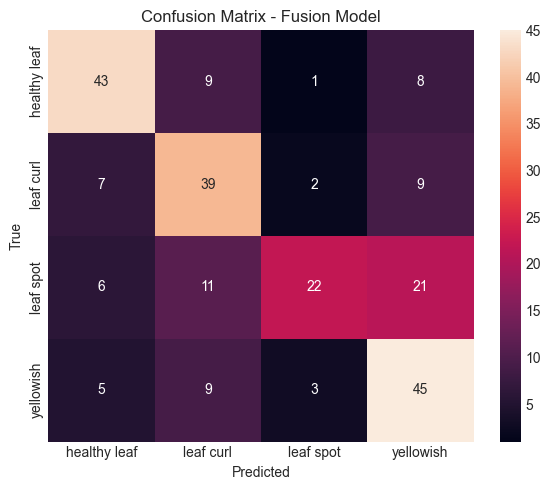

In [23]:
model_f, base1, base2 = build_fusion()
model_f, history_f, timing_f = train_model(model_f, None)
eval_f = evaluate_model(model_f, "Fusion Model", return_details=True)
acc_f = eval_f["accuracy"]

# 9. Perbandingan Hasil

In [ ]:
print("\n=== HASIL AKHIR ===")
print(f"MobileNetV2   : {acc_m}")
print(f"EfficientNet  : {acc_e}")
print(f"Fusion Model  : {acc_f}")


=== HASIL AKHIR ===
MobileNetV2   : 0.23749999701976776
EfficientNet  : 0.4791666567325592
Fusion Model  : 0.25


# 10. Visualisasi Hasil dan Performa 3 Model

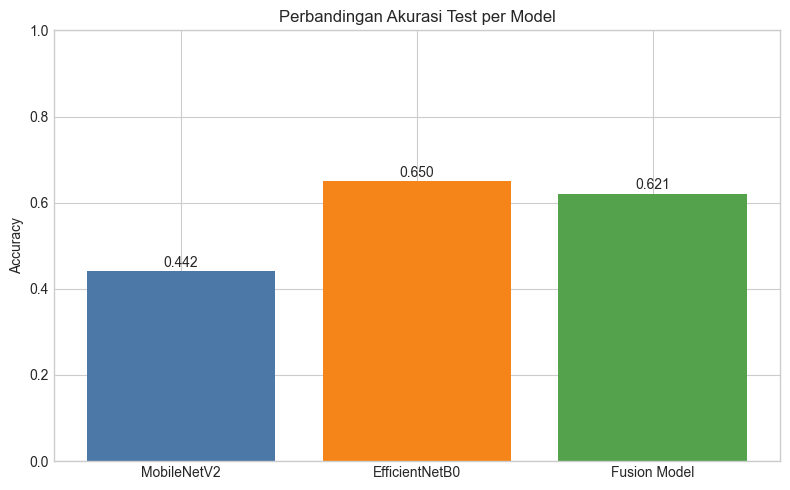

Model akurasi tertinggi: EfficientNetB0 (0.6500)
Peningkatan Hybrid vs MobileNetV2: +17.92%


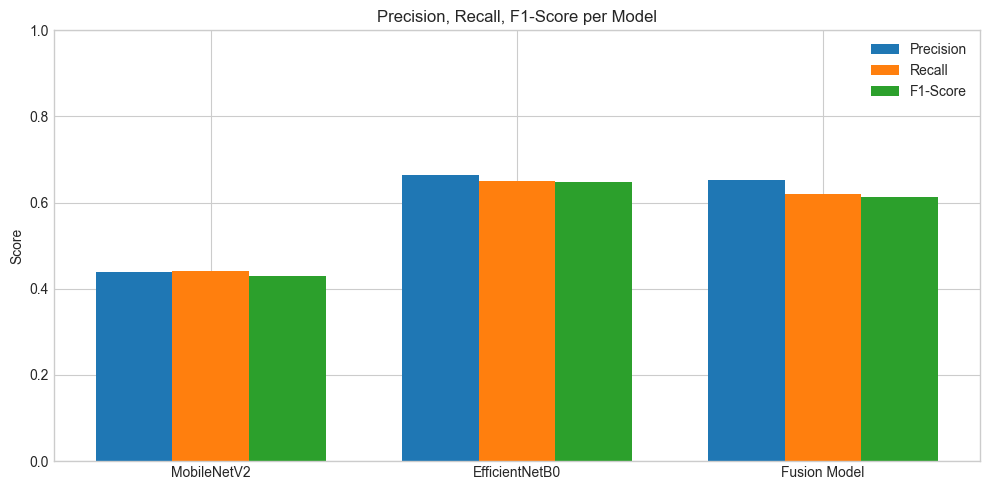

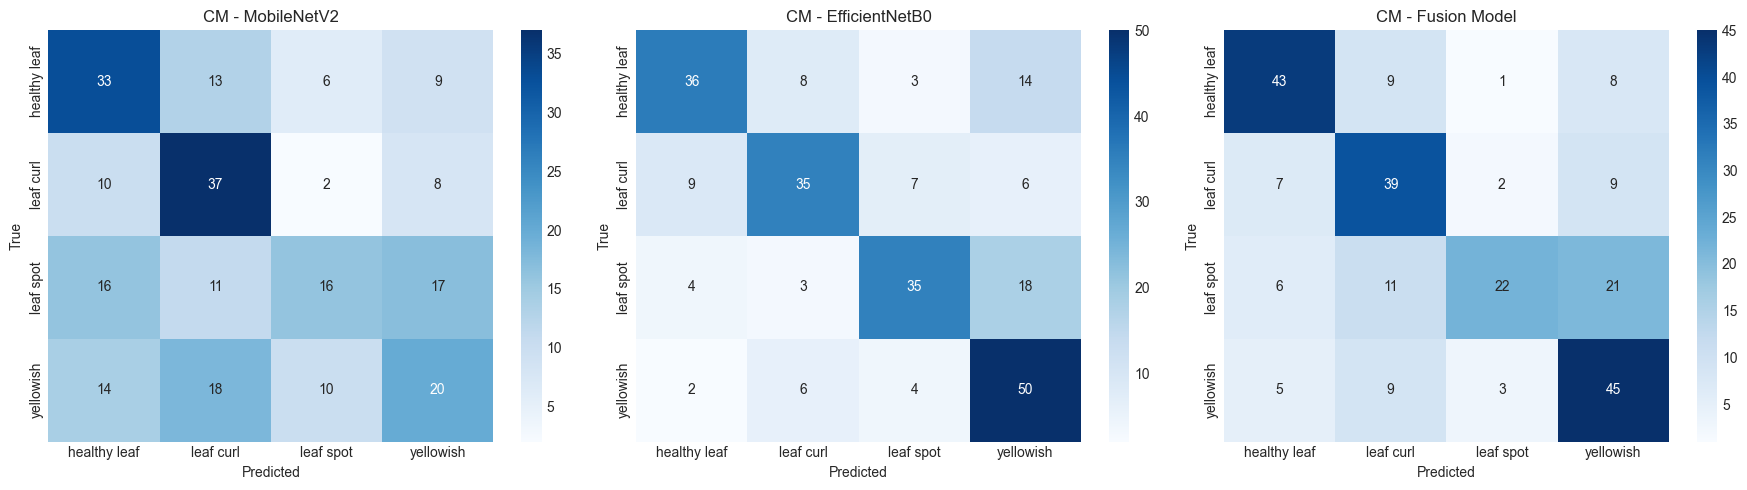

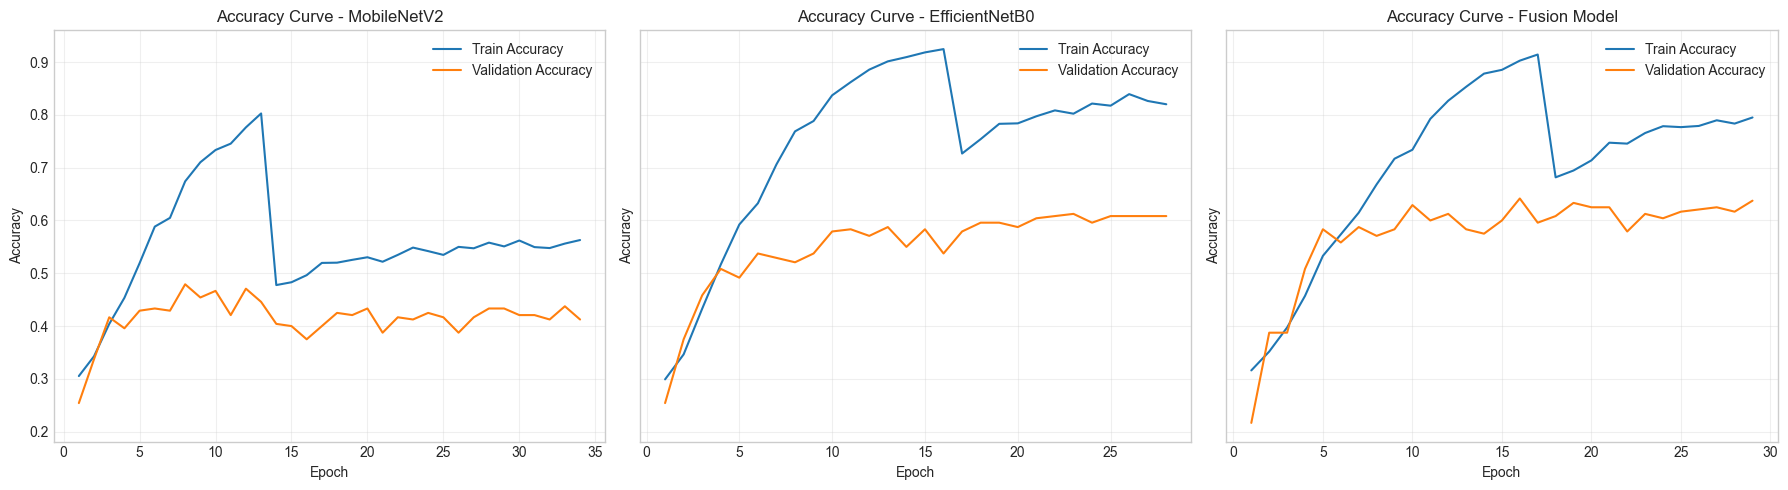

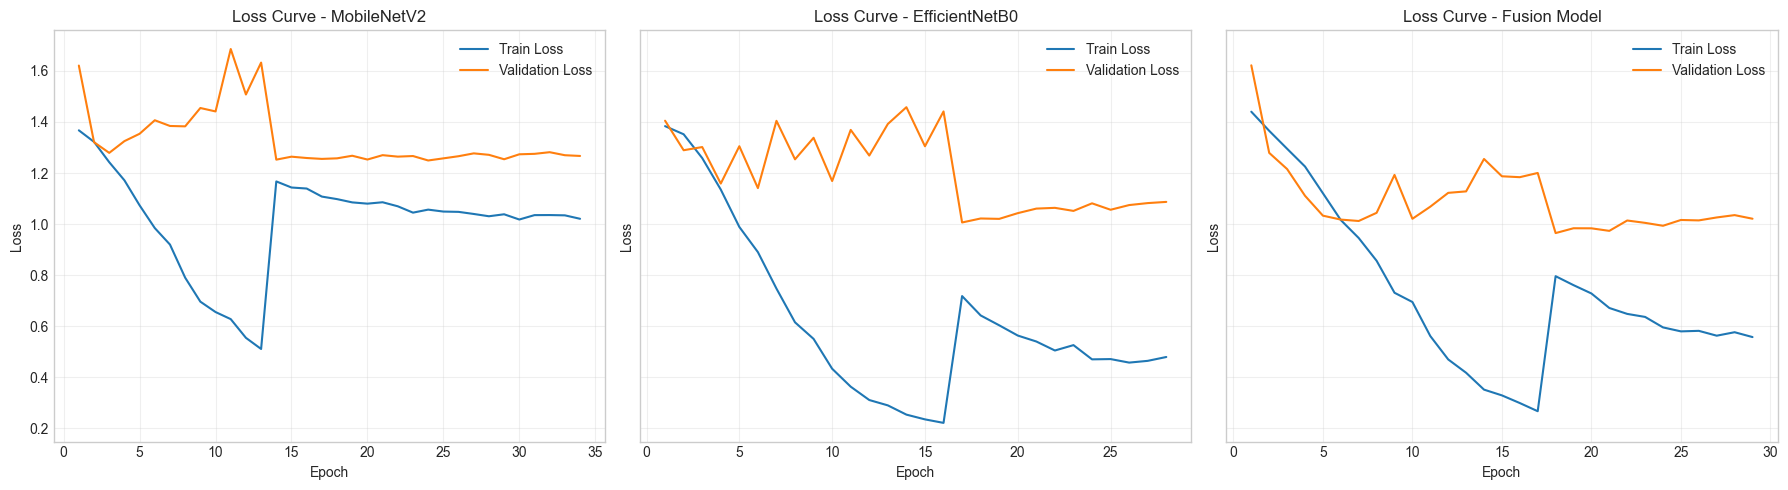

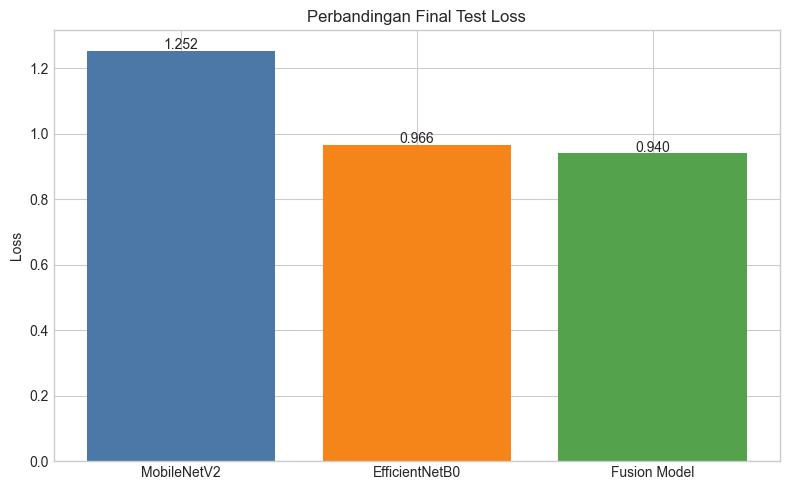

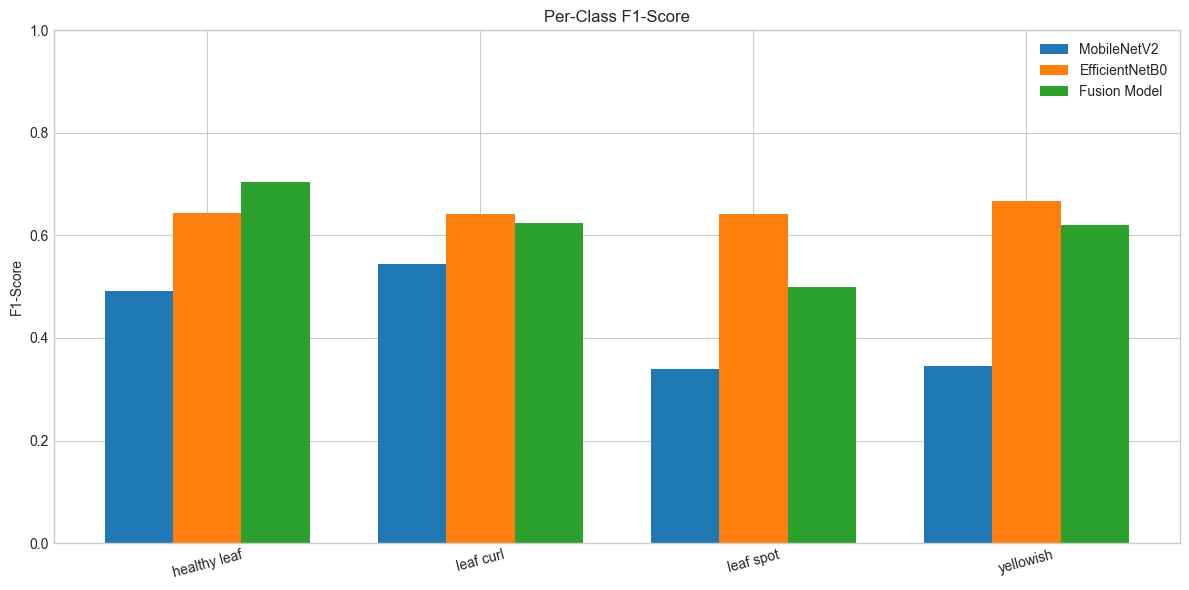

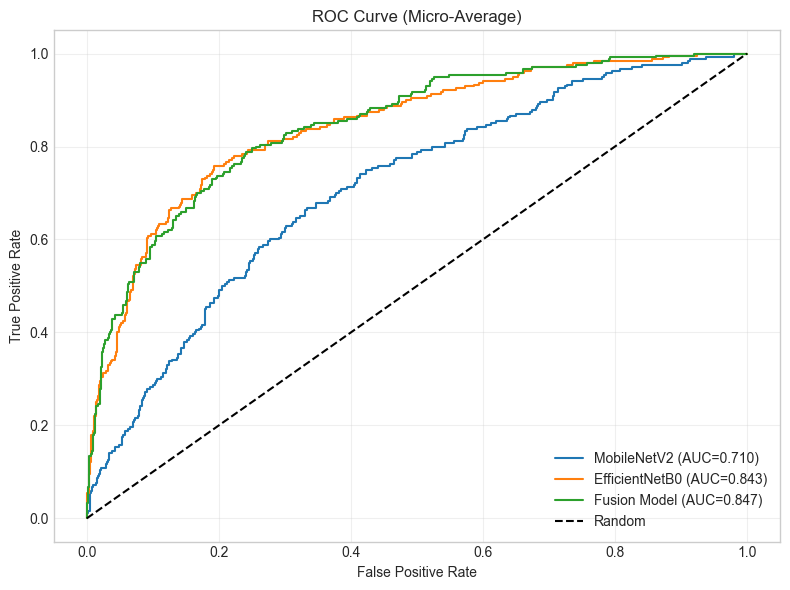

,Model,Accuracy,Precision,Recall,F1-Score,Test Loss,AUC,Training Time (sec)
1,EfficientNetB0,0.6500,0.6646,0.6500,0.6487,0.9663,0.8432,312.9562
2,Fusion Model,0.6208,0.6519,0.6208,0.6127,0.9398,0.8467,524.0128
0,MobileNetV2,0.4417,0.4395,0.4417,0.4286,1.2522,0.7104,368.3042


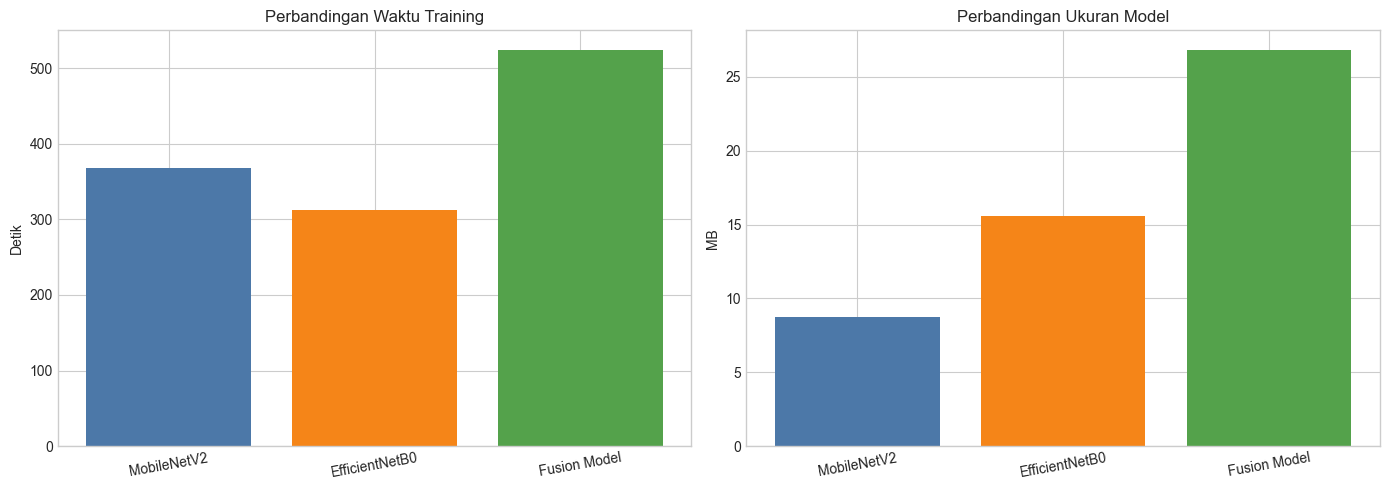


Insight cepat:
- Akurasi tertinggi: EfficientNetB0
- Gain Hybrid vs MobileNetV2: +17.92%
- Cek gap train vs validation untuk indikasi overfitting.
- Cek confusion matrix untuk kelas yang masih sering tertukar.


In [24]:
from IPython.display import display

model_results = {
    "MobileNetV2": eval_m,
    "EfficientNetB0": eval_e,
    "Fusion Model": eval_f,
}

history_available = all(name in globals() for name in ["history_m", "history_e", "history_f"])
timing_available = all(name in globals() for name in ["timing_m", "timing_e", "timing_f"])

model_histories = {
    "MobileNetV2": history_m,
    "EfficientNetB0": history_e,
    "Fusion Model": history_f,
}
model_timings = {
    "MobileNetV2": timing_m,
    "EfficientNetB0": timing_e,
    "Fusion Model": timing_f,
}

class_names = eval_m["class_names"]


def merge_history(history_bundle):
    train_acc = history_bundle["stage1"]["accuracy"] + history_bundle["stage2"]["accuracy"]
    val_acc = history_bundle["stage1"]["val_accuracy"] + history_bundle["stage2"]["val_accuracy"]
    train_loss = history_bundle["stage1"]["loss"] + history_bundle["stage2"]["loss"]
    val_loss = history_bundle["stage1"]["val_loss"] + history_bundle["stage2"]["val_loss"]
    return train_acc, val_acc, train_loss, val_loss


def get_model_size_mb(model, filename):
    temp_path = Path(filename)
    torch.save(model.state_dict(), temp_path)
    size_mb = temp_path.stat().st_size / (1024 ** 2)
    temp_path.unlink(missing_ok=True)
    return size_mb


acc_df = pd.DataFrame({
    "Model": list(model_results.keys()),
    "Accuracy": [v["accuracy"] for v in model_results.values()],
})
plt.figure(figsize=(8, 5))
bars = plt.bar(acc_df["Model"], acc_df["Accuracy"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi Test per Model")
plt.ylabel("Accuracy")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.show()

best_model = acc_df.sort_values("Accuracy", ascending=False).iloc[0]
hybrid_gain_vs_mobilenet = (model_results["Fusion Model"]["accuracy"] - model_results["MobileNetV2"]["accuracy"]) * 100
print(f"Model akurasi tertinggi: {best_model['Model']} ({best_model['Accuracy']:.4f})")
print(f"Peningkatan Hybrid vs MobileNetV2: {hybrid_gain_vs_mobilenet:+.2f}%")

metric_rows = []
for model_name, result in model_results.items():
    weighted = result["report_dict"]["weighted avg"]
    metric_rows.append({
        "Model": model_name,
        "Precision": weighted["precision"],
        "Recall": weighted["recall"],
        "F1-Score": weighted["f1-score"],
    })
metrics_df = pd.DataFrame(metric_rows)

x = np.arange(len(metrics_df))
width = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - width, metrics_df["Precision"], width=width, label="Precision")
plt.bar(x, metrics_df["Recall"], width=width, label="Recall")
plt.bar(x + width, metrics_df["F1-Score"], width=width, label="F1-Score")
plt.xticks(x, metrics_df["Model"])
plt.ylim(0, 1)
plt.title("Precision, Recall, F1-Score per Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (model_name, result) in zip(axes, model_results.items()):
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
    )
    ax.set_title(f"CM - {model_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

if history_available:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (model_name, history_bundle) in zip(axes, model_histories.items()):
        train_acc, val_acc, _, _ = merge_history(history_bundle)
        epochs = np.arange(1, len(train_acc) + 1)
        ax.plot(epochs, train_acc, label="Train Accuracy")
        ax.plot(epochs, val_acc, label="Validation Accuracy")
        ax.set_title(f"Accuracy Curve - {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

if history_available:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    for ax, (model_name, history_bundle) in zip(axes, model_histories.items()):
        _, _, train_loss, val_loss = merge_history(history_bundle)
        epochs = np.arange(1, len(train_loss) + 1)
        ax.plot(epochs, train_loss, label="Train Loss")
        ax.plot(epochs, val_loss, label="Validation Loss")
        ax.set_title(f"Loss Curve - {model_name}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()

loss_df = pd.DataFrame({
    "Model": list(model_results.keys()),
    "Final Test Loss": [v["loss"] for v in model_results.values()],
})
plt.figure(figsize=(8, 5))
bars = plt.bar(loss_df["Model"], loss_df["Final Test Loss"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Perbandingan Final Test Loss")
plt.ylabel("Loss")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.show()

per_class_rows = []
for model_name, result in model_results.items():
    for cls in class_names:
        per_class_rows.append({
            "Model": model_name,
            "Class": cls,
            "F1-Score": result["report_dict"][cls]["f1-score"],
        })
per_class_df = pd.DataFrame(per_class_rows)

plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_results.keys()):
    subset = per_class_df[per_class_df["Model"] == model_name]
    plt.bar(np.arange(len(class_names)) + i * 0.25, subset["F1-Score"], width=0.25, label=model_name)
plt.xticks(np.arange(len(class_names)) + 0.25, class_names, rotation=15)
plt.ylim(0, 1)
plt.title("Per-Class F1-Score")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.show()

auc_scores = {}
plt.figure(figsize=(8, 6))
classes = np.arange(len(class_names))
for model_name, result in model_results.items():
    y_true_bin = label_binarize(result["y_true"], classes=classes)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), result["y_prob"].ravel())
    roc_auc = auc(fpr, tpr)
    auc_scores[model_name] = roc_auc
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro-Average)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

summary_rows = []
for model_name, result in model_results.items():
    w = result["report_dict"]["weighted avg"]
    summary_rows.append({
        "Model": model_name,
        "Accuracy": result["accuracy"],
        "Precision": w["precision"],
        "Recall": w["recall"],
        "F1-Score": w["f1-score"],
        "Test Loss": result["loss"],
        "AUC": auc_scores[model_name],
        "Training Time (sec)": model_timings[model_name]["total_sec"],
    })
summary_df = pd.DataFrame(summary_rows).sort_values("Accuracy", ascending=False)
display(summary_df.round(4))

model_sizes_mb = {
    "MobileNetV2": get_model_size_mb(model_m, "tmp_model_m.pt"),
    "EfficientNetB0": get_model_size_mb(model_e, "tmp_model_e.pt"),
    "Fusion Model": get_model_size_mb(model_f, "tmp_model_f.pt"),
}

efficiency_df = pd.DataFrame({
    "Model": list(model_timings.keys()),
    "Training Time (sec)": [v["total_sec"] for v in model_timings.values()],
    "Model Size (MB)": [model_sizes_mb[name] for name in model_timings.keys()],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(efficiency_df["Model"], efficiency_df["Training Time (sec)"], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Perbandingan Waktu Training")
axes[0].set_ylabel("Detik")
axes[0].tick_params(axis='x', rotation=10)

axes[1].bar(efficiency_df["Model"], efficiency_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
axes[1].set_title("Perbandingan Ukuran Model")
axes[1].set_ylabel("MB")
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

print("\nInsight cepat:")
print(f"- Akurasi tertinggi: {summary_df.iloc[0]['Model']}")
print(f"- Gain Hybrid vs MobileNetV2: {hybrid_gain_vs_mobilenet:+.2f}%")
print("- Cek gap train vs validation untuk indikasi overfitting.")
print("- Cek confusion matrix untuk kelas yang masih sering tertukar.")

# 11. Export Grafik dan Tabel ke Folder Reports

In [26]:
from pathlib import Path

base_dir = Path.cwd()
fig_dir = base_dir / "reports" / "figures"
metrics_dir = base_dir / "reports" / "metrics"
fig_dir.mkdir(parents=True, exist_ok=True)
metrics_dir.mkdir(parents=True, exist_ok=True)

acc_df.to_csv(metrics_dir / "accuracy_per_model.csv", index=False)
metrics_df.to_csv(metrics_dir / "precision_recall_f1_per_model.csv", index=False)
loss_df.to_csv(metrics_dir / "final_loss_per_model.csv", index=False)
per_class_df.to_csv(metrics_dir / "f1_per_class_per_model.csv", index=False)
summary_df.to_csv(metrics_dir / "classification_summary_table.csv", index=False)
size_df = efficiency_df[["Model", "Model Size (MB)"]].copy()
size_df.to_csv(metrics_dir / "model_size_comparison.csv", index=False)
efficiency_df.to_csv(metrics_dir / "training_time_and_model_size.csv", index=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(acc_df["Model"], acc_df["Accuracy"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.ylim(0, 1)
plt.title("Perbandingan Akurasi Test per Model")
plt.ylabel("Accuracy")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.01, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.savefig(fig_dir / "01_accuracy_per_model.png", dpi=300, bbox_inches="tight")
plt.close()

x = np.arange(len(metrics_df))
width = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - width, metrics_df["Precision"], width=width, label="Precision")
plt.bar(x, metrics_df["Recall"], width=width, label="Recall")
plt.bar(x + width, metrics_df["F1-Score"], width=width, label="F1-Score")
plt.xticks(x, metrics_df["Model"])
plt.ylim(0, 1)
plt.title("Precision, Recall, F1-Score per Model")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "02_precision_recall_f1_grouped.png", dpi=300, bbox_inches="tight")
plt.close()

for idx, (model_name, result) in enumerate(model_results.items(), start=1):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    filename = f"03_confusion_matrix_{idx}_{model_name.lower().replace(' ', '_')}.png"
    plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
    plt.close()

if history_available:
    for idx, (model_name, history_bundle) in enumerate(model_histories.items(), start=1):
        train_acc, val_acc, _, _ = merge_history(history_bundle)
        epochs = np.arange(1, len(train_acc) + 1)
        plt.figure(figsize=(7, 5))
        plt.plot(epochs, train_acc, label="Train Accuracy")
        plt.plot(epochs, val_acc, label="Validation Accuracy")
        plt.title(f"Accuracy Curve - {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        filename = f"04_accuracy_curve_{idx}_{model_name.lower().replace(' ', '_')}.png"
        plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
        plt.close()

    for idx, (model_name, history_bundle) in enumerate(model_histories.items(), start=1):
        _, _, train_loss, val_loss = merge_history(history_bundle)
        epochs = np.arange(1, len(train_loss) + 1)
        plt.figure(figsize=(7, 5))
        plt.plot(epochs, train_loss, label="Train Loss")
        plt.plot(epochs, val_loss, label="Validation Loss")
        plt.title(f"Loss Curve - {model_name}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(alpha=0.3)
        plt.legend()
        plt.tight_layout()
        filename = f"05_loss_curve_{idx}_{model_name.lower().replace(' ', '_')}.png"
        plt.savefig(fig_dir / filename, dpi=300, bbox_inches="tight")
        plt.close()

plt.figure(figsize=(8, 5))
bars = plt.bar(loss_df["Model"], loss_df["Final Test Loss"], color=["#4C78A8", "#F58518", "#54A24B"])
plt.title("Perbandingan Final Test Loss")
plt.ylabel("Loss")
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, h + 0.005, f"{h:.3f}", ha="center")
plt.tight_layout()
plt.savefig(fig_dir / "06_final_loss_per_model.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(12, 6))
for i, model_name in enumerate(model_results.keys()):
    subset = per_class_df[per_class_df["Model"] == model_name]
    plt.bar(np.arange(len(class_names)) + i * 0.25, subset["F1-Score"], width=0.25, label=model_name)
plt.xticks(np.arange(len(class_names)) + 0.25, class_names, rotation=15)
plt.ylim(0, 1)
plt.title("Per-Class F1-Score")
plt.ylabel("F1-Score")
plt.legend()
plt.tight_layout()
plt.savefig(fig_dir / "07_f1_per_class_grouped.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(8, 6))
classes = np.arange(len(class_names))
for model_name, result in model_results.items():
    y_true_bin = label_binarize(result["y_true"], classes=classes)
    fpr, tpr, _ = roc_curve(y_true_bin.ravel(), result["y_prob"].ravel())
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Micro-Average)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(fig_dir / "08_roc_curve_micro_average.png", dpi=300, bbox_inches="tight")
plt.close()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(efficiency_df["Model"], efficiency_df["Training Time (sec)"], color=["#4C78A8", "#F58518", "#54A24B"])
axes[0].set_title("Perbandingan Waktu Training")
axes[0].set_ylabel("Detik")
axes[0].tick_params(axis='x', rotation=10)

axes[1].bar(efficiency_df["Model"], efficiency_df["Model Size (MB)"], color=["#4C78A8", "#F58518", "#54A24B"])
axes[1].set_title("Perbandingan Ukuran Model")
axes[1].set_ylabel("MB")
axes[1].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.savefig(fig_dir / "10_efficiency_time_and_size.png", dpi=300, bbox_inches="tight")
plt.close()

print(f"Export selesai: {fig_dir}")
print(f"Export selesai: {metrics_dir}")

Export selesai: d:\Kuliah\SKRIPSI\MODEL 2 (sekunder)\reports\figures
Export selesai: d:\Kuliah\SKRIPSI\MODEL 2 (sekunder)\reports\metrics
